In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from mpl_toolkits.mplot3d import Axes3D


In [2]:
def loss_function(w1, w2):
    return (w1**2 + w2 - 11)**2 + (w1 + w2**2 - 7)**2


In [3]:
def gradients(w1, w2):
    dJ_dw1 = 4*w1*(w1**2 + w2 - 11) + 2*(w1 + w2**2 - 7)
    dJ_dw2 = 2*(w1**2 + w2 - 11) + 4*w2*(w1 + w2**2 - 7)
    return dJ_dw1, dJ_dw2


In [4]:
initial_w1 = -4
initial_w2 = 0

learning_rate = 0.01
iterations = 200


In [5]:
def gradient_descent():
    w1, w2 = initial_w1, initial_w2
    w1_hist, w2_hist, loss_hist = [], [], []
    
    for i in range(iterations):
        d1, d2 = gradients(w1, w2)
        
        w1 -= learning_rate * d1
        w2 -= learning_rate * d2
        
        w1_hist.append(w1)
        w2_hist.append(w2)
        loss_hist.append(loss_function(w1, w2))
    
    return w1_hist, w2_hist, loss_hist


In [6]:
def stochastic_gradient_descent():
    w1, w2 = initial_w1, initial_w2
    w1_hist, w2_hist, loss_hist = [], [], []
    
    for i in range(iterations):
        d1, d2 = gradients(w1, w2)
        
        noise1 = np.random.normal(0, 0.1)
        noise2 = np.random.normal(0, 0.1)
        
        w1 -= learning_rate * (d1 + noise1)
        w2 -= learning_rate * (d2 + noise2)
        
        w1_hist.append(w1)
        w2_hist.append(w2)
        loss_hist.append(loss_function(w1, w2))
    
    return w1_hist, w2_hist, loss_hist


In [7]:
def mini_batch_gradient_descent():
    w1, w2 = initial_w1, initial_w2
    w1_hist, w2_hist, loss_hist = [], [], []
    
    for i in range(iterations):
        d1, d2 = gradients(w1, w2)
        
        noise1 = np.random.normal(0, 0.05)
        noise2 = np.random.normal(0, 0.05)
        
        w1 -= learning_rate * (d1 + noise1)
        w2 -= learning_rate * (d2 + noise2)
        
        w1_hist.append(w1)
        w2_hist.append(w2)
        loss_hist.append(loss_function(w1, w2))
    
    return w1_hist, w2_hist, loss_hist


In [8]:
def adagrad():
    w1, w2 = initial_w1, initial_w2
    G1, G2 = 0, 0
    epsilon = 1e-8
    
    w1_hist, w2_hist, loss_hist = [], [], []
    
    for i in range(iterations):
        d1, d2 = gradients(w1, w2)
        
        G1 += d1**2
        G2 += d2**2
        
        w1 -= learning_rate / np.sqrt(G1 + epsilon) * d1
        w2 -= learning_rate / np.sqrt(G2 + epsilon) * d2
        
        w1_hist.append(w1)
        w2_hist.append(w2)
        loss_hist.append(loss_function(w1, w2))
    
    return w1_hist, w2_hist, loss_hist


In [9]:
def nesterov():
    w1, w2 = initial_w1, initial_w2
    v1, v2 = 0, 0
    momentum = 0.9
    
    w1_hist, w2_hist, loss_hist = [], [], []
    
    for i in range(iterations):
        lookahead_w1 = w1 - momentum * v1
        lookahead_w2 = w2 - momentum * v2
        
        d1, d2 = gradients(lookahead_w1, lookahead_w2)
        
        v1 = momentum * v1 + learning_rate * d1
        v2 = momentum * v2 + learning_rate * d2
        
        w1 -= v1
        w2 -= v2
        
        w1_hist.append(w1)
        w2_hist.append(w2)
        loss_hist.append(loss_function(w1, w2))
    
    return w1_hist, w2_hist, loss_hist


In [10]:
def rmsprop():
    w1, w2 = initial_w1, initial_w2
    beta = 0.9
    E1, E2 = 0, 0
    epsilon = 1e-8
    
    w1_hist, w2_hist, loss_hist = [], [], []
    
    for i in range(iterations):
        d1, d2 = gradients(w1, w2)
        
        E1 = beta * E1 + (1 - beta) * d1**2
        E2 = beta * E2 + (1 - beta) * d2**2
        
        w1 -= learning_rate / np.sqrt(E1 + epsilon) * d1
        w2 -= learning_rate / np.sqrt(E2 + epsilon) * d2
        
        w1_hist.append(w1)
        w2_hist.append(w2)
        loss_hist.append(loss_function(w1, w2))
    
    return w1_hist, w2_hist, loss_hist


In [11]:
def adam():
    w1, w2 = initial_w1, initial_w2
    m1 = m2 = 0
    v1 = v2 = 0
    beta1 = 0.9
    beta2 = 0.999
    epsilon = 1e-8
    
    w1_hist, w2_hist, loss_hist = [], [], []
    
    for t in range(1, iterations+1):
        d1, d2 = gradients(w1, w2)
        
        m1 = beta1*m1 + (1-beta1)*d1
        m2 = beta1*m2 + (1-beta1)*d2
        
        v1 = beta2*v1 + (1-beta2)*d1**2
        v2 = beta2*v2 + (1-beta2)*d2**2
        
        m1_hat = m1 / (1 - beta1**t)
        m2_hat = m2 / (1 - beta1**t)
        v1_hat = v1 / (1 - beta2**t)
        v2_hat = v2 / (1 - beta2**t)
        
        w1 -= learning_rate * m1_hat / (np.sqrt(v1_hat) + epsilon)
        w2 -= learning_rate * m2_hat / (np.sqrt(v2_hat) + epsilon)
        
        w1_hist.append(w1)
        w2_hist.append(w2)
        loss_hist.append(loss_function(w1, w2))
    
    return w1_hist, w2_hist, loss_hist


In [12]:
results = {
    "GD": gradient_descent(),
    "SGD": stochastic_gradient_descent(),
    "MiniBatch": mini_batch_gradient_descent(),
    "Nesterov": nesterov(),
    "Adagrad": adagrad(),
    "RMSProp": rmsprop(),
    "Adam": adam()
}


In [13]:
w1_vals = np.linspace(-6, 6, 200)
w2_vals = np.linspace(-6, 6, 200)
W1, W2 = np.meshgrid(w1_vals, w2_vals)
Z = loss_function(W1, W2)


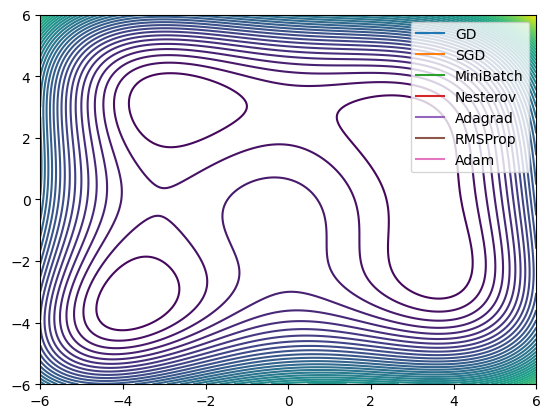

In [14]:
fig, ax = plt.subplots()
ax.contour(W1, W2, Z, levels=50)

lines = {}
for name in results:
    line, = ax.plot([], [], label=name)
    lines[name] = line

ax.legend()

def update(frame):
    for name in results:
        w1_hist, w2_hist, _ = results[name]
        lines[name].set_data(w1_hist[:frame], w2_hist[:frame])
    return lines.values()

ani = animation.FuncAnimation(fig, update, frames=iterations, interval=50)
plt.show()


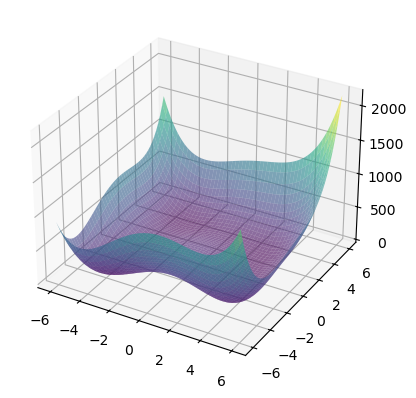

In [15]:
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(W1, W2, Z, cmap='viridis', alpha=0.6)

points = {}
for name in results:
    point, = ax.plot([], [], [], 'o')
    points[name] = point

def update3d(frame):
    for name in results:
        w1_hist, w2_hist, loss_hist = results[name]
        points[name].set_data(w1_hist[frame], w2_hist[frame])
        points[name].set_3d_properties(loss_hist[frame])
    return points.values()

ani3d = animation.FuncAnimation(fig, update3d, frames=iterations, interval=50)
plt.show()


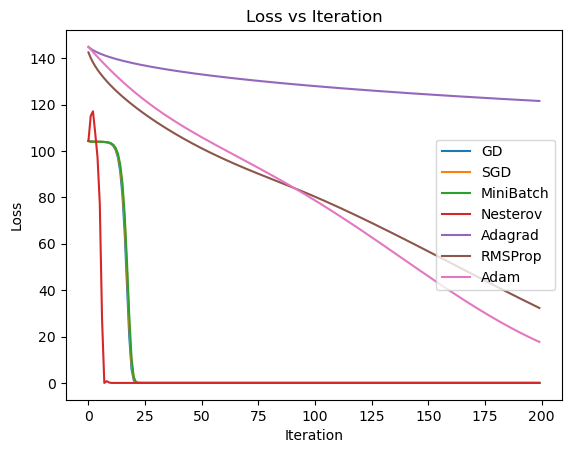

In [16]:
plt.figure()

for name in results:
    _, _, loss_hist = results[name]
    plt.plot(loss_hist, label=name)

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.title("Loss vs Iteration")
plt.show()
